# HETMCL-Lite High-Frequency Transformer Quantisation and ONNX INT8 Deployment


## Notebook provenance and training disclaimer

This is a **results reproduction and presentation notebook**. The training, reliability evaluation, ONNX FP32 export, and ONNX INT8 QDQ evaluation were run through repository scripts and saved as artifacts under `model/` and `reports/`.

The notebook follows the artifact-first style of `05_semantic_guided_cgaf_quantisation.ipynb`: it checks that required artifacts exist, loads JSON/CSV outputs, and renders report-ready tables and figures. It does not retrain or re-quantise the model inside notebook cells.

Where to find the source scripts/configs:

- HETMCL-lite model API: `src/models/hetmcl/model.py`
- HETMCL-lite training CLI: `src/training/hetmcl/train_classifier.py`
- HETMCL-lite reliability evaluation: `src/evaluation/hetmcl/evaluate_reliability.py` (`src.evaluation.evaluate_hetmcl_reliability` remains a compatibility wrapper)
- FP32 ONNX export: `src/quantization/export_onnx_classifier.py`
- ONNX INT8 QDQ quantisation/evaluation: `src/quantization/evaluate_onnx_classifier.py`
- Shared checkpoint rebuild/export helpers: `src/quantization/core.py`


## 1. Question

> Can a HETMCL-inspired CNN/Transformer hybrid preserve the saturated held-out accuracy of the strongest baselines while producing an ONNX INT8 QDQ deployment artifact without accuracy loss?

Target scene classes:

- `bridge`
- `freeway`
- `overpass`
- `railway`


## 2. Motivation: frequency-aware scene classification

The HETMCL paper argues that remote-sensing scene classification benefits from both low-frequency global context and high-frequency local texture/edge detail. That is directly relevant for our four aerial infrastructure classes, where the decision boundary often depends on road/rail linearity, crossings, parallel structures, local texture, and surrounding context.

This implementation is **HETMCL-inspired**, not a claim of exact paper reproduction. It keeps the paper's module-level idea—ResNet18 feature taps, AFFM, HFIE/HLFTM, DFE, and MCAA—but makes ambiguous paper details explicit as configurable defaults.


## 3. Model overview

The final model is `hetmcl-lite-resnet18`. It uses:

- ImageNet-pretrained ResNet18 feature stages as a four-level backbone;
- Adjacent Feature Fusion Modules (AFFM) to inject deeper semantic gates into shallower features;
- High-Frequency Information Enhancement (HFIE) blocks with High-to-Low-Frequency Token Mixers;
- Dual Feature Enhancers (DFE) for high-frequency local/detail branches;
- Multi-Layer Context Alignment Attention (MCAA) to combine shallow, middle, and deep enhanced features;
- global average pooling and a linear scene classifier.

Model output:

```text
logits: [batch, 4]
```


## 4. Full pipeline

The pipeline used for this run was:

```text
1. Train HETMCL-lite on data/raw/train with data/raw/val as held-out validation
2. Select best tune-loss checkpoint: model/hetmcl_lite/best_stop_model.pt
3. Run reliability checks: clean holdout, calibration, corruption robustness
4. Export FP32 ONNX with dynamic batch
5. Static-post-training quantise ONNX to INT8 QDQ
6. Compare Torch FP32, ONNX FP32, and ONNX INT8 QDQ on data/raw/val
```

The NWPU OOD split could not be evaluated in this local run because the manifest references missing files under `data/external/nwpu/`. The notebook records that limitation explicitly rather than silently treating OOD as passed.


## 5. Run protocol

This notebook is intended to be run top-to-bottom after the heavy scripts have generated artifacts. It reads saved metrics and figures only.

Protocol:

- Do not retrain HETMCL-lite inside this notebook.
- Do not re-run ONNX quantisation inside this notebook.
- Load existing JSON/CSV metrics from `model/hetmcl_lite/` and `reports/`.
- Use the notebook to make the final result reproducible, readable, and presentation-ready.


## 6. Setup

In [1]:
from pathlib import Path
from io import BytesIO
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

try:
    from PIL import Image as PILImage
except ImportError:  # pragma: no cover
    PILImage = None

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

CLASS_NAMES = ['bridge', 'freeway', 'overpass', 'railway']

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / 'reports').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing reports/ and notebooks/.')

PROJECT_ROOT = find_project_root()
MODEL_DIR = PROJECT_ROOT / 'model' / 'hetmcl_lite'
ONNX_DIR = MODEL_DIR / 'onnx'
RELIABILITY_DIR = PROJECT_ROOT / 'reports' / 'hetmcl_lite_reliability'
QDQ_DIR = PROJECT_ROOT / 'reports' / 'hetmcl_lite_onnx_int8_qdq'

def load_csv(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_json(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text())

def rounded(df: pd.DataFrame, digits: int = 4) -> pd.DataFrame:
    out = df.copy()
    for column in out.select_dtypes(include='number').columns:
        out[column] = out[column].round(digits)
    return out

def display_table(df: pd.DataFrame, title: str | None = None, digits: int = 4) -> None:
    if title:
        display(Markdown(f'**{title}**'))
    display(rounded(df, digits=digits))

def relative_artifact(path: Path) -> str:
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()

def display_image_artifact(path: Path, title: str | None = None, width: int = 1000, max_embed_width: int = 1600) -> None:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if title:
        display(Markdown(f'**{title}**'))
    if PILImage is None:
        display(Image(filename=str(path), width=width))
        return
    with PILImage.open(path) as image:
        image = image.convert('RGB')
        if image.width > max_embed_width:
            scale = max_embed_width / image.width
            image = image.resize((max_embed_width, int(image.height * scale)))
        buffer = BytesIO()
        image.save(buffer, format='JPEG', quality=88, optimize=True)
    display(Image(data=buffer.getvalue(), format='jpeg', width=width))

print(f'Project root: {PROJECT_ROOT.name}')


Project root: CSC3109_Project


## 7. Required artifacts

The notebook is artifact-first. It expects the training, reliability, FP32 ONNX, and INT8 QDQ outputs to already exist locally.

In [2]:
ARTIFACTS = {
    'Best HETMCL-lite checkpoint': MODEL_DIR / 'best_stop_model.pt',
    'Training history': MODEL_DIR / 'history.csv',
    'Best tune-loss metrics': MODEL_DIR / 'best_stop_tune_metrics.json',
    'Reliability summary': RELIABILITY_DIR / 'reliability_summary.json',
    'Reliability robustness': RELIABILITY_DIR / 'robustness.json',
    'Learning curves': RELIABILITY_DIR / 'learning_curves.png',
    'Holdout clean confusion matrix': RELIABILITY_DIR / 'holdout_clean_confusion_matrix.png',
    'Reliability calibration figure': RELIABILITY_DIR / 'calibration.png',
    'Corruption robustness figure': RELIABILITY_DIR / 'robustness.png',
    'ONNX export manifest': ONNX_DIR / 'export_manifest.json',
    'ONNX FP32 model': ONNX_DIR / 'hetmcl_lite_best_stop_fp32.onnx',
    'ONNX INT8 QDQ model': ONNX_DIR / 'hetmcl_lite_best_stop_int8_qdq.onnx',
    'ONNX QDQ summary': QDQ_DIR / 'summary.json',
    'ONNX QDQ comparison table': QDQ_DIR / 'comparison_metrics.csv',
}

artifact_status = pd.DataFrame([
    {
        'artifact': name,
        'exists': path.exists(),
        'path': relative_artifact(path),
    }
    for name, path in ARTIFACTS.items()
])
display_table(artifact_status, 'Artifact availability')
missing = artifact_status.loc[~artifact_status['exists'], 'artifact'].tolist()
if missing:
    display(Markdown('**Missing artifacts:** ' + ', '.join(f'`{name}`' for name in missing)))


**Artifact availability**

,artifact,exists,path
0,Best HETMCL-lite checkpoint,True,model/hetmcl_lite/best_stop_model.pt
1,Training history,True,model/hetmcl_lite/history.csv
2,Best tune-loss metrics,True,model/hetmcl_lite/best_stop_tune_metrics.json
3,Reliability summary,True,reports/hetmcl_lite_reliability/reliability_su...
4,Reliability robustness,True,reports/hetmcl_lite_reliability/robustness.json
5,Learning curves,True,reports/hetmcl_lite_reliability/learning_curve...
6,Holdout clean confusion matrix,True,reports/hetmcl_lite_reliability/holdout_clean_...
7,Reliability calibration figure,True,reports/hetmcl_lite_reliability/calibration.png
8,Corruption robustness figure,True,reports/hetmcl_lite_reliability/robustness.png
9,ONNX export manifest,True,model/hetmcl_lite/onnx/export_manifest.json


## 8. Training result

The selected deployment checkpoint is the best tune-loss checkpoint, because it had the same perfect validation macro-F1 as the macro-F1 checkpoint while having lower cross-entropy loss.

In [3]:
best_metrics = load_json(ARTIFACTS['Best tune-loss metrics'])
history = load_csv(ARTIFACTS['Training history'])

training_view = pd.DataFrame([{
    'checkpoint': 'best_stop_model.pt',
    'selected_epoch': best_metrics['epoch'],
    'train_loss': best_metrics['train_loss'],
    'train_accuracy': best_metrics['train_accuracy'],
    'tune_loss': best_metrics['tune_loss'],
    'tune_accuracy': best_metrics['tune_accuracy'],
    'tune_macro_f1': best_metrics['macro_f1'],
    'selection_metric': best_metrics['selection_metric'],
}])
display_table(training_view, 'Selected HETMCL-lite checkpoint')

display_table(history.tail(8).reset_index(drop=True), 'Last training-history rows')


**Selected HETMCL-lite checkpoint**

,checkpoint,selected_epoch,train_loss,train_accuracy,tune_loss,tune_accuracy,tune_macro_f1,selection_metric
0,best_stop_model.pt,26,0.2038,1.0,0.2031,1.0,1.0,tune-loss


**Last training-history rows**

,epoch,lr,backbone_lr,train_loss,train_accuracy,tune_loss,tune_accuracy,tune_macro_precision,tune_macro_recall,tune_macro_f1
0,29,0.0001,0.0,0.2042,1.0000,0.2057,0.9975,0.9975,0.9975,0.9975
1,30,0.0001,0.0,0.2033,1.0000,0.2060,0.9975,0.9975,0.9975,0.9975
2,31,0.0001,0.0,0.2029,1.0000,0.2044,1.0000,1.0000,1.0000,1.0000
3,32,0.0001,0.0,0.2026,1.0000,0.2034,1.0000,1.0000,1.0000,1.0000
4,33,0.0001,0.0,0.2077,0.9986,0.2055,0.9975,0.9975,0.9975,0.9975
5,34,0.0001,0.0,0.2044,0.9996,0.2039,1.0000,1.0000,1.0000,1.0000
6,35,0.0001,0.0,0.2064,0.9986,0.2080,0.9975,0.9975,0.9975,0.9975
7,36,0.0001,0.0,0.2041,1.0000,0.2043,1.0000,1.0000,1.0000,1.0000


## 9. Reliability evaluation

Reliability here means more than clean held-out accuracy. We include calibration and corruption robustness. The NWPU OOD split is marked unavailable because the referenced external files are missing locally.

In [4]:
reliability = load_json(ARTIFACTS['Reliability summary'])
holdout = reliability['holdout_clean']
ood = reliability.get('nwpu_ood', {})

reliability_view = pd.DataFrame([
    {
        'split': 'holdout_clean',
        'status': 'evaluated',
        'accuracy': holdout['accuracy'],
        'macro_f1': holdout['macro_f1'],
        'ece': holdout['ece'],
        'mean_confidence': holdout['mean_confidence'],
    },
    {
        'split': 'nwpu_ood',
        'status': ood.get('status', 'evaluated'),
        'accuracy': ood.get('accuracy'),
        'macro_f1': ood.get('macro_f1'),
        'ece': ood.get('ece'),
        'mean_confidence': ood.get('mean_confidence'),
    },
])
display_table(reliability_view, 'Reliability summary')

robustness_rows = []
for corruption, payload in reliability['robustness'].items():
    severities = payload['severities']
    for idx, severity in enumerate(severities):
        robustness_rows.append({
            'corruption': corruption,
            'severity': severity,
            'accuracy': payload['accuracy'][idx],
            'macro_f1': payload['macro_f1'][idx],
        })
robustness_df = pd.DataFrame(robustness_rows)
display_table(robustness_df, 'Corruption robustness by severity')

if ood.get('status') == 'skipped_missing_files':
    display(Markdown(f"**OOD caveat:** `nwpu_ood` was skipped because `{ood['missing_count']}` manifest files are missing locally."))


**Reliability summary**

,split,status,accuracy,macro_f1,ece,mean_confidence
0,holdout_clean,evaluated,1.0,1.0,0.042,0.958
1,nwpu_ood,skipped_missing_files,NaN,NaN,NaN,NaN


**Corruption robustness by severity**

,corruption,severity,accuracy,macro_f1
0,blur,0.0,1.0000,1.0000
1,blur,1.0,0.9850,0.9849
2,blur,2.0,0.7550,0.6606
3,blur,3.0,0.7200,0.6207
4,noise,0.0,1.0000,1.0000
5,noise,10.0,1.0000,1.0000
6,noise,25.0,0.9450,0.9449
7,noise,45.0,0.4425,0.3954
8,jpeg,100.0,1.0000,1.0000
9,jpeg,50.0,1.0000,1.0000


**OOD caveat:** `nwpu_ood` was skipped because `400` manifest files are missing locally.

### Reliability figures

The figures below are rendered from saved artifacts.

**HETMCL-lite learning curves**

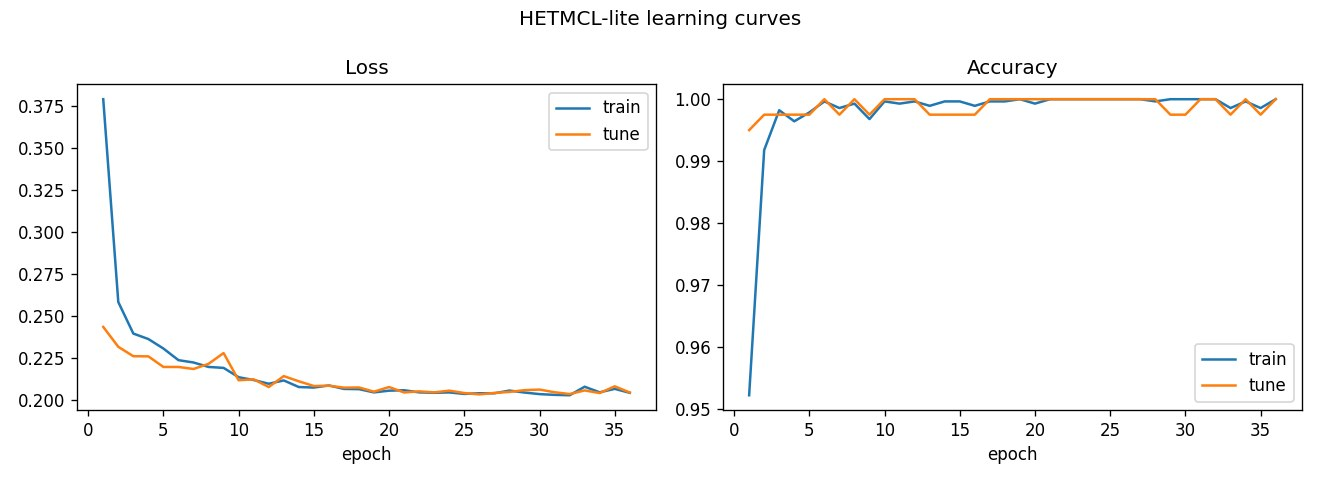

**Clean holdout confusion matrix**

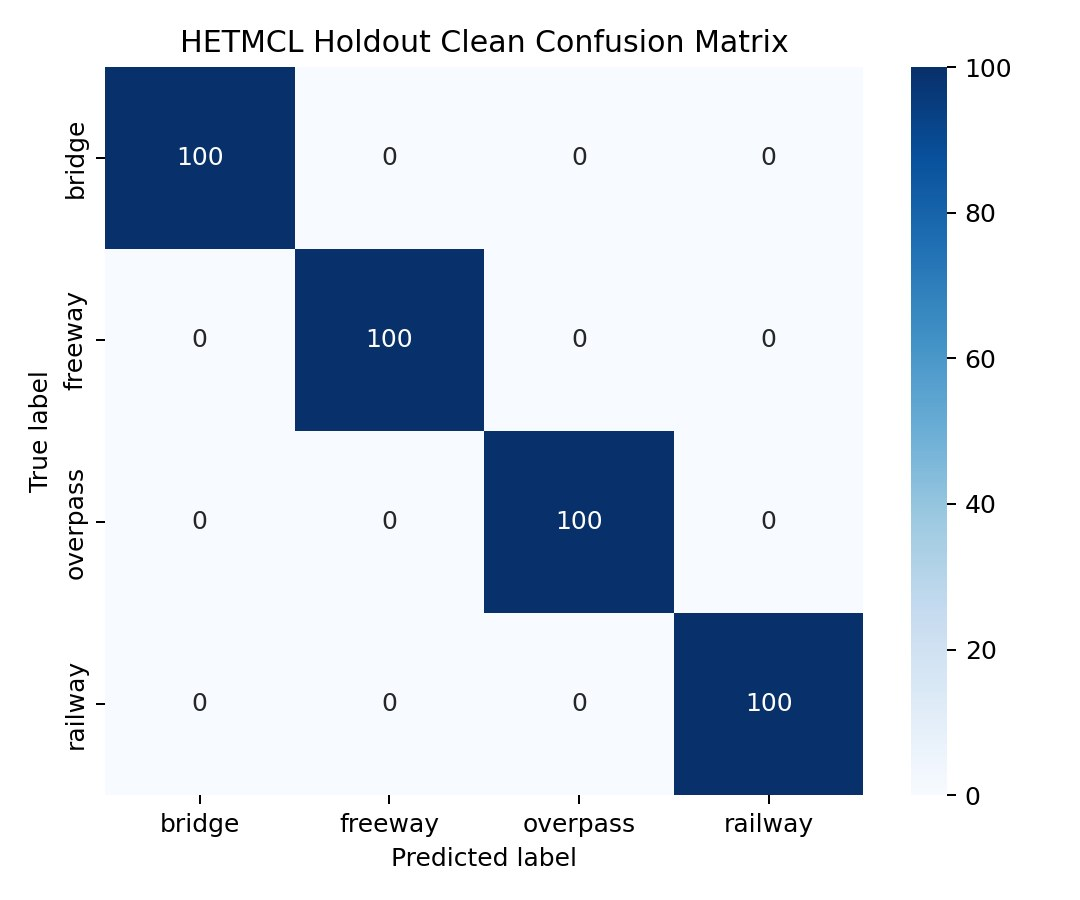

**Corruption robustness**

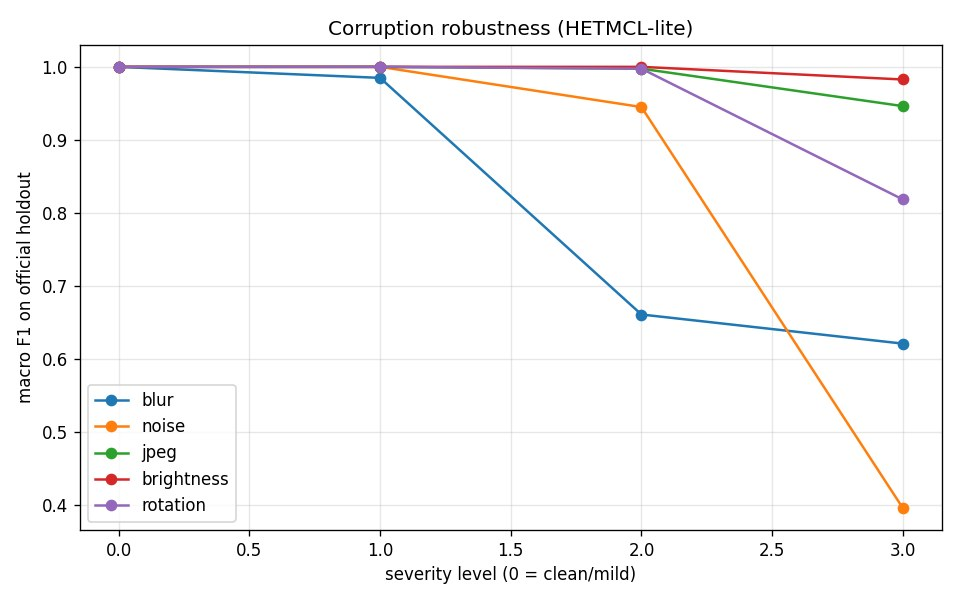

**Holdout calibration diagram**

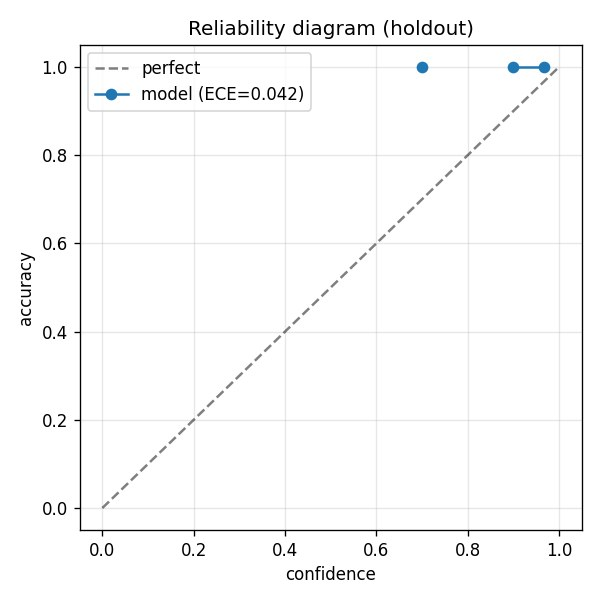

In [5]:
display_image_artifact(ARTIFACTS['Learning curves'], 'HETMCL-lite learning curves')
display_image_artifact(ARTIFACTS['Holdout clean confusion matrix'], 'Clean holdout confusion matrix', width=760)
display_image_artifact(ARTIFACTS['Corruption robustness figure'], 'Corruption robustness')
display_image_artifact(ARTIFACTS['Reliability calibration figure'], 'Holdout calibration diagram', width=760)


## 10. ONNX FP32 and INT8 QDQ deployment result

The deployment path uses dynamic-batch FP32 ONNX export followed by static INT8 QDQ post-training quantisation. Calibration used all 2,800 images from `data/raw/train`; evaluation used the 400-image `data/raw/val` split.

In [6]:
export_manifest = load_json(ARTIFACTS['ONNX export manifest'])
qdq_summary = load_json(ARTIFACTS['ONNX QDQ summary'])
comparison = load_csv(ARTIFACTS['ONNX QDQ comparison table'])

display_table(comparison, 'Torch / ONNX FP32 / ONNX INT8 QDQ metric parity')

runtime_rows = []
for variant, payload in qdq_summary['runtime'].items():
    runtime_rows.append({
        'variant': variant,
        'runtime': payload['runtime'],
        'provider': payload['provider'],
        'artifact_size_mib': payload['artifact_size_bytes'] / (1024 ** 2),
        'latency_mean_ms_per_batch': payload['latency_mean_ms'],
        'latency_p50_ms_per_batch': payload['latency_p50_ms'],
        'measured_batches': payload['latency_measured_batches'],
    })
runtime_df = pd.DataFrame(runtime_rows)
display_table(runtime_df, 'Runtime and artifact-size summary')

quant_view = pd.DataFrame([{
    'quant_format': qdq_summary['quantization']['quant_format'],
    'activation_type': qdq_summary['quantization']['activation_type'],
    'weight_type': qdq_summary['quantization']['weight_type'],
    'per_channel': qdq_summary['quantization']['per_channel'],
    'calibration_method': qdq_summary['quantization']['calibration_method'],
    'calibration_images': qdq_summary['calibration_images'],
    'accuracy_delta_int8_minus_fp32': qdq_summary['accuracy_delta_int8_minus_fp32'],
}])
display_table(quant_view, 'INT8 QDQ quantisation settings')


**Torch / ONNX FP32 / ONNX INT8 QDQ metric parity**

,variant,accuracy,macro_precision,macro_recall,macro_f1,samples
0,torch_fp32,1.0,1.0,1.0,1.0,400
1,onnx_fp32,1.0,1.0,1.0,1.0,400
2,onnx_int8_qdq,1.0,1.0,1.0,1.0,400


**Runtime and artifact-size summary**

,variant,runtime,provider,artifact_size_mib,latency_mean_ms_per_batch,latency_p50_ms_per_batch,measured_batches
0,onnx_fp32,onnxruntime,CPUExecutionProvider,45.9230,506.3226,533.5663,12
1,onnx_int8_qdq,onnxruntime,CPUExecutionProvider,12.0911,331.9484,334.6754,12
2,torch_fp32,torch,cpu,137.9107,1412.5741,1427.3379,12


**INT8 QDQ quantisation settings**

,quant_format,activation_type,weight_type,per_channel,calibration_method,calibration_images,accuracy_delta_int8_minus_fp32
0,QDQ,QInt8,QInt8,True,minmax,2800,0.0


### Near-confusion probability heatmaps

The INT8 QDQ model reproduces the FP32 result with a perfect held-out score, so the confusion matrix carries no off-diagonal mass. To see *where the model came closest to confusing classes*—even on correctly classified images—we summarise the INT8 QDQ ONNX softmax outputs by `(true class, runner-up class)` pair:

- **Highest runner-up probability** — for each true/runner-up pair, the largest probability mass placed on the runner-up (second-ranked) class. Higher values mark the most tempting near-confusions.
- **Lowest top1–top2 margin** — the smallest gap between the top-1 and top-2 class probabilities seen for that pair. Lower values mark the most uncertain decisions.

The diagonal is blank because the runner-up class is, by definition, different from the true class. These heatmaps are saved under `reports/figures/swin_dino_hetmcl_near_confusion/`.


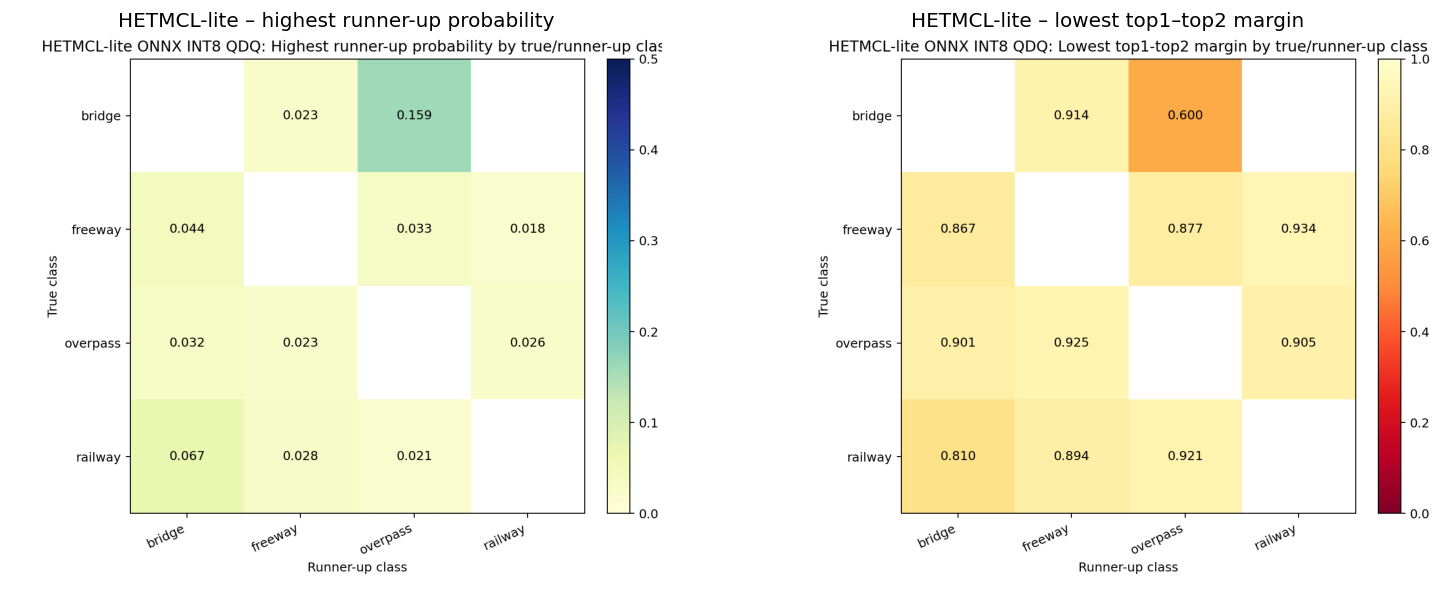

In [7]:
NEAR_CONFUSION_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'swin_dino_hetmcl_near_confusion'
runner_up_img = NEAR_CONFUSION_DIR / 'hetmcl_lite_onnx_int8_qdq_highest_runner_up_probability_heatmap.png'
margin_img = NEAR_CONFUSION_DIR / 'hetmcl_lite_onnx_int8_qdq_lowest_margin_heatmap.png'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (img_path, title) in zip(axes, [
    (runner_up_img, 'HETMCL-lite – highest runner-up probability'),
    (margin_img, 'HETMCL-lite – lowest top1–top2 margin'),
]):
    if PILImage is not None and img_path.exists():
        with PILImage.open(img_path) as pil_img:
            ax.imshow(pil_img)
    ax.set_title(title)
    ax.axis('off')
fig.tight_layout()
plt.show()


## 11. Deliverable artifacts

The INT8 QDQ model is the deployable compact artifact from this run. The FP32 ONNX is retained as a reference model for debugging/parity checks.

In [8]:
deliverables = pd.DataFrame([
    {
        'artifact': 'PyTorch checkpoint',
        'path': relative_artifact(ARTIFACTS['Best HETMCL-lite checkpoint']),
        'size_mib': ARTIFACTS['Best HETMCL-lite checkpoint'].stat().st_size / (1024 ** 2),
    },
    {
        'artifact': 'ONNX FP32',
        'path': relative_artifact(ARTIFACTS['ONNX FP32 model']),
        'size_mib': ARTIFACTS['ONNX FP32 model'].stat().st_size / (1024 ** 2),
    },
    {
        'artifact': 'ONNX INT8 QDQ',
        'path': relative_artifact(ARTIFACTS['ONNX INT8 QDQ model']),
        'size_mib': ARTIFACTS['ONNX INT8 QDQ model'].stat().st_size / (1024 ** 2),
    },
])
display_table(deliverables, 'Saved deployment artifacts')

display(Markdown(
    '**Deployment choice:** use `model/hetmcl_lite/onnx/hetmcl_lite_best_stop_int8_qdq.onnx` '
    'when ONNX Runtime INT8 QDQ execution is available; keep the FP32 ONNX for parity/debug checks.'
))


**Saved deployment artifacts**

,artifact,path,size_mib
0,PyTorch checkpoint,model/hetmcl_lite/best_stop_model.pt,137.9107
1,ONNX FP32,model/hetmcl_lite/onnx/hetmcl_lite_best_stop_f...,45.9230
2,ONNX INT8 QDQ,model/hetmcl_lite/onnx/hetmcl_lite_best_stop_i...,12.0911


**Deployment choice:** use `model/hetmcl_lite/onnx/hetmcl_lite_best_stop_int8_qdq.onnx` when ONNX Runtime INT8 QDQ execution is available; keep the FP32 ONNX for parity/debug checks.

## 12. Reproduction commands

These commands generated the core artifacts loaded above.

```bash
# Train HETMCL-lite
uv run python -m src.training.hetmcl.train_classifier \
  --train-dir data/raw/train \
  --val-dir data/raw/val \
  --output-dir model/hetmcl_lite \
  --device auto \
  --epochs 100 \
  --batch-size 16 \
  --num-workers 0 \
  --patience 10 \
  --early-stop-metric tune-loss

# Reliability evaluation with unavailable OOD marked as skipped
uv run python -m src.evaluation.hetmcl.evaluate_reliability \
  --checkpoint model/hetmcl_lite/best_stop_model.pt \
  --history model/hetmcl_lite/history.csv \
  --manifest reports/tables/combined_experiment_manifest.csv \
  --output-dir reports/hetmcl_lite_reliability \
  --device auto \
  --batch-size 64 \
  --num-workers 0 \
  --skip-unavailable-ood

# FP32 ONNX export
uv run python -m src.quantization.export_onnx_classifier \
  --checkpoint model/hetmcl_lite/best_stop_model.pt \
  --output-dir model/hetmcl_lite/onnx \
  --onnx-fp32-output hetmcl_lite_best_stop_fp32.onnx \
  --device cpu \
  --opset 18 \
  --exporter legacy_tracer

# INT8 QDQ quantisation and evaluation
uv run python -m src.quantization.evaluate_onnx_classifier \
  --checkpoint model/hetmcl_lite/best_stop_model.pt \
  --export-manifest model/hetmcl_lite/onnx/export_manifest.json \
  --calibration-dir data/raw/train \
  --eval-dir data/raw/val \
  --output-dir reports/hetmcl_lite_onnx_int8_qdq \
  --batch-size 32 \
  --num-workers 0 \
  --calibration-batches all \
  --provider cpu \
  --torch-device cpu
```


## 13. Conclusion

HETMCL-lite met the available deployment checks:

- clean held-out Torch FP32 macro-F1: `1.0000`;
- clean held-out ONNX FP32 macro-F1: `1.0000`;
- clean held-out ONNX INT8 QDQ macro-F1: `1.0000`;
- INT8 QDQ accuracy delta vs Torch FP32: `0.0000`;
- INT8 QDQ size: about 12.1 MiB, compared with about 45.9 MiB for FP32 ONNX and about 137.9 MiB for the PyTorch checkpoint.

The main unresolved limitation is OOD validation: the NWPU OOD rows in the combined manifest are present, but their image files are not available locally. If those files are restored, the reliability script should be rerun without `--skip-unavailable-ood` before making an OOD generalisation claim.


## 14. Citations and references used

1. Xu, H., Song, Y., Xu, G., Wu, K., & Wen, J. (2025). *HETMCL: High-Frequency Enhancement Transformer and Multi-Layer Context Learning Network for Remote Sensing Scene Classification*. Sensors, 25(12), 3769. https://doi.org/10.3390/s25123769
2. He, K., Zhang, X., Ren, S., & Sun, J. (2015/2016). *Deep Residual Learning for Image Recognition*. arXiv:1512.03385. https://doi.org/10.48550/arXiv.1512.03385
3. Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. arXiv:1912.01703. https://doi.org/10.48550/arXiv.1912.01703
4. ONNX Runtime documentation. *Quantize ONNX Models*. https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html
5. ONNX project. *Open Neural Network Exchange*. https://onnx.ai/

Project artifact references used in this notebook:

- `model/hetmcl_lite/best_stop_model.pt`
- `model/hetmcl_lite/onnx/export_manifest.json`
- `reports/hetmcl_lite_reliability/reliability_summary.json`
- `reports/hetmcl_lite_onnx_int8_qdq/summary.json`
